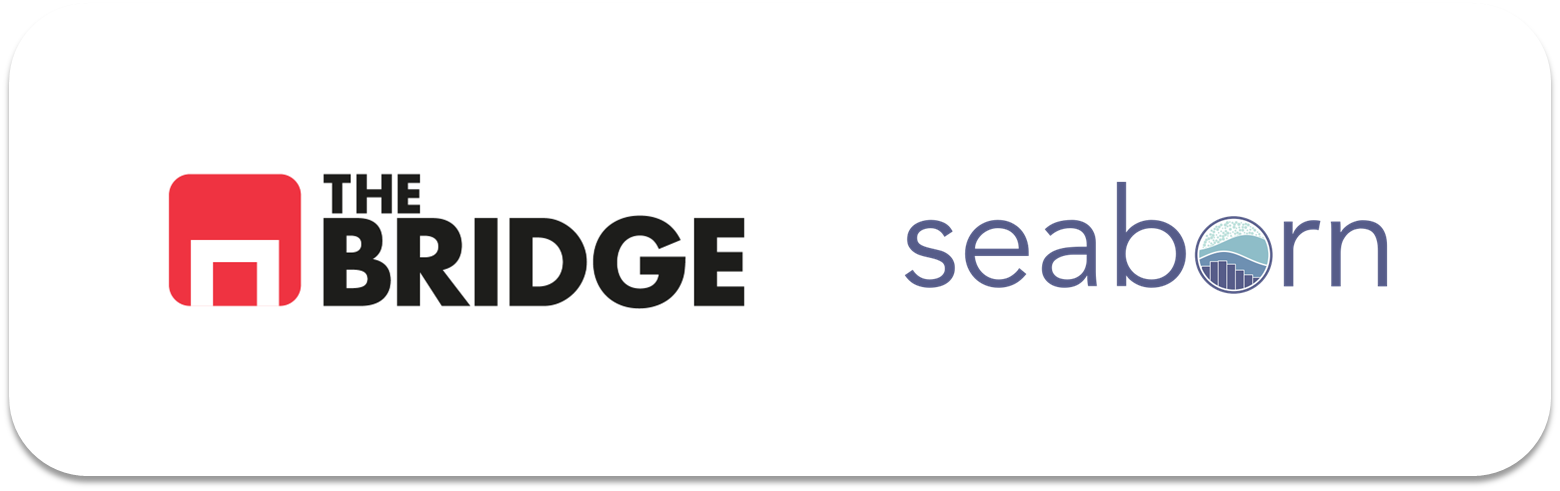

## PRACTICA OBLIGATORIA: **Visualización Avanzada y Presentación**

* La práctica obligatoria de esta unidad se divide en dos partes, una dedicada a visualización y construcción de funciones, y la otra a hacer una presentación de resultados. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## #1: Visualización

### #1.1

Carga el dataset de las ciudades de California que está en la ruta "./data/california_cities.csv". Muestra su contenido, deshazte de las filas con nulos.

In [15]:
df_california = pd.read_csv("./data/california_cities.csv")

df_california.dropna(inplace=True)

df_california


,Unnamed: 0,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
4,4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01
5,5,AlisoViejo,33.575000,-117.725556,127.0,417.0,47823,7.472,7.472,0.000,19.352,19.352,0.000,0.00
6,6,Alturas,41.487222,-120.542500,1332.0,4370.0,2827,2.449,2.435,0.014,6.342,6.306,0.036,0.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
477,477,Yountville,38.403056,-122.362222,30.0,98.0,2933,1.531,1.531,0.000,3.966,3.966,0.000,0.00
478,478,Yreka,41.726667,-122.637500,787.0,2582.0,7765,10.053,9.980,0.073,26.036,25.847,0.188,0.72
479,479,YubaCity,39.134722,-121.626111,18.0,59.0,64925,14.656,14.578,0.078,37.959,37.758,0.201,0.53
480,480,Yucaipa,34.030278,-117.048611,798.0,2618.0,51367,27.893,27.888,0.005,72.244,72.231,0.013,0.02


In [16]:
df_california.info()

<class 'pandas.core.frame.DataFrame'>
Index: 427 entries, 0 to 481
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          427 non-null    int64  
 1   city                427 non-null    object 
 2   latd                427 non-null    float64
 3   longd               427 non-null    float64
 4   elevation_m         427 non-null    float64
 5   elevation_ft        427 non-null    float64
 6   population_total    427 non-null    int64  
 7   area_total_sq_mi    427 non-null    float64
 8   area_land_sq_mi     427 non-null    float64
 9   area_water_sq_mi    427 non-null    float64
 10  area_total_km2      427 non-null    float64
 11  area_land_km2       427 non-null    float64
 12  area_water_km2      427 non-null    float64
 13  area_water_percent  427 non-null    float64
dtypes: float64(11), int64(2), object(1)
memory usage: 50.0+ KB


### #1.2

Crea una función similar a la que se pide en el ejercicio 6 de la segunda tanda de ejercicios del workout. Es decir, una función para pintar diagramas de dispersion que tenga seis argumentos, pero ojo al cambio en el quinto:
1. Un dataframe
2. Una columna numérica del dataframe
3. Una columna numérica del dataframe diferente a la anterior.
4. Un columna categórica (Opcional, valor por defecto None)
5. Un valor para el tamaño de los puntos o una cadena, pero que puede ser una cadena de caracteres, en cuyo caso se debe interpretar como una de las columnas del dataframe cuyos valores deben controlar el tamaño
6. Un sexto argumento "escala", que permita manipular la escala del tamaño en el caso de que el quinto argumento sea una cadena. Este argumento multiplicará a los valores de la columna indicada en el parámetro anterior (así si quiero dividir por 10000, este sexto argumento tendrá que valer 1/10000)

La función debe pintar el diagrama de dispersión de la columna numérica 1, en el eje X, frente a la columna numérica 2, en el eje Y, usando un código de colores en función de la columna categórica y con el tamaño de los puntos según el argumento correspondiente. 

Si no se diera una columna categórica como argumento, el color no debe pasarse como parámetro a la función de Seaborn o Matplotlib que uses.

EXTRA: Añade un argumento que controle si la función pinta una leyenda para colores y tamaños o un colorbar y una leyenda para los tamaños. NO TE PREOCUPES POR EL FORMATO DE LA LEYENDA (lo veremos en la sesión en vivo)

In [25]:
def scatter_custom(df_california, x, y, categoria=None, size=40, escala=1):
    """
    df: dataframe
    x: columna numérica eje X
    y: columna numérica eje Y
    categoria: columna categórica para color (opcional)
    size: número o nombre de columna para tamaño
    escala: multiplicador del tamaño si size es columna
    """
    
    # Determinar tamaño
    if isinstance(size, str):
        tamaños = df_california[size] * escala
    else:
        tamaños = size
    
    # Crear gráfico
    plt.figure(figsize=(8,6))

    if categoria is None:
        sns.scatterplot(data=df_california, x=x, y=y, s=tamaños)
    else:
        sns.scatterplot(data=df_california, x=x, y=y, hue=categoria, s=tamaños)
    
    plt.title(f"{y} vs {x}")
    plt.show()

### #1.3

Pinta el diagrama de dispersión de longitud y latitud (longitud en las x, latitud en las y) de las ciudades, usando el tamaño de las ciudades para el tamaño de los puntos y los colores para mostrar la población. Previamente crea una columna nueva "log_poblacion" y asignale el log decimal de la poblacion (np.log10() y como argumento los valores de la columna "population_total"). Usa "log_poblacion" para el color.

Un ejemplo de como podría salir para que lo tengas de referencia: (olvidate de la leyenda, auque si quieres como extra puedes intentar ver cómo crearla así)

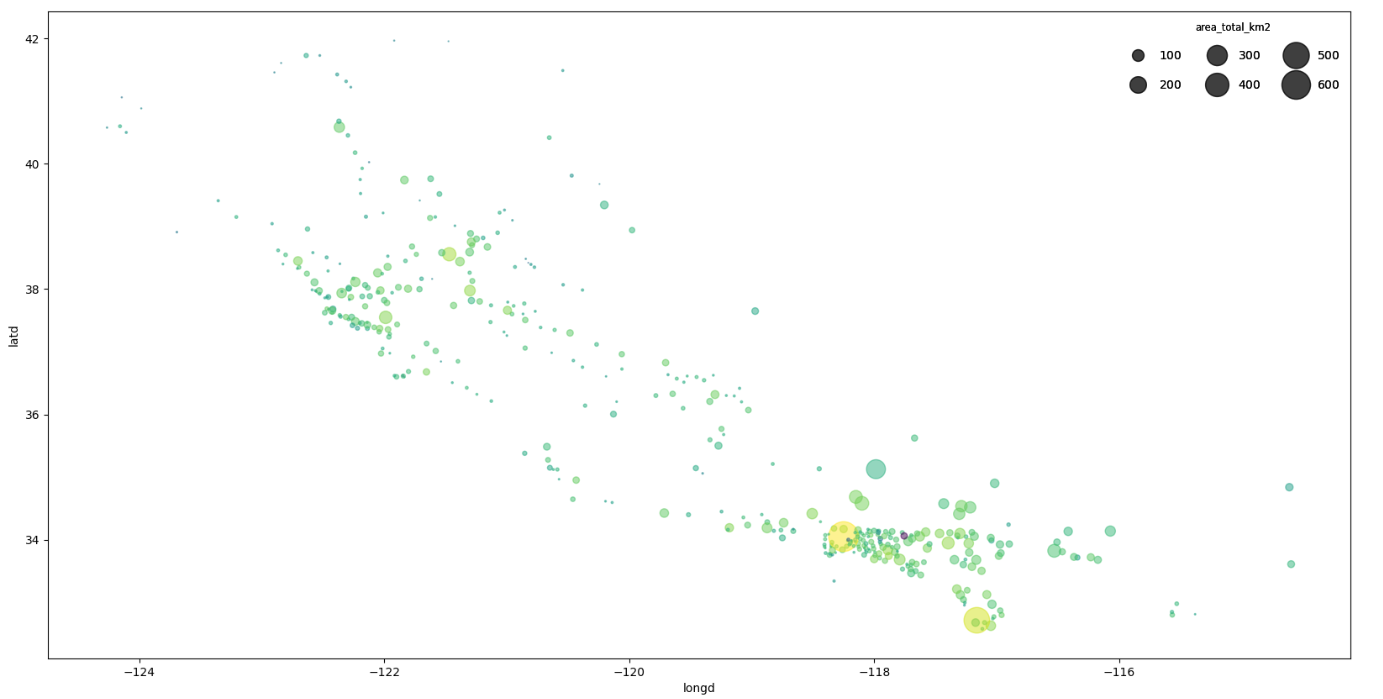

In [26]:
df_california["log_poblacion"] = np.log10(df_california["population_total"])

TypeError: cannot convert the series to <class 'float'>

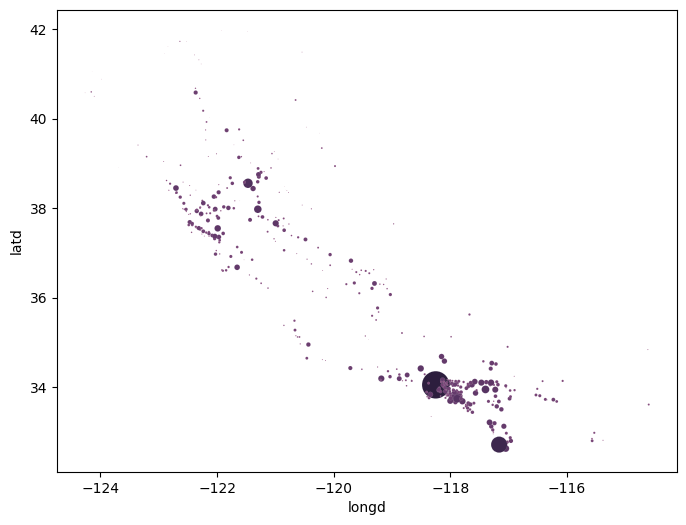

In [30]:
scatter_custom(
    df_california,
    x="longd",
    y="latd",
    categoria="log_poblacion",
    size="population_total",
    escala=1/10000
)

## #2: Presentación

En esta parte tendrás que hacer dos cosas:

#2.1 Crear una presentación sencilla sobre el Titanic de no más de 6 slides, sin incluir portada, con los siguientes mensajes y su apoyo en datos:  

1. El titanic fue un accidente con una tasa de mortalidad alta.  

2. Los datos apoyan que se dio el "Las mujeres y los niños primero", pero...  
3. ...la clase en la que viajases tuvo una influencia significativa y podría explicar...  
4. ...las diferencias entre tasas de supervivencia de mujeres y niños.    
5. Además, aunque el puerto de embarque parece tener influencia, se podría asumir que más bien fue la clase de pasaje que embarcó en cada uno de ellos.  

In [2]:
df_titanic = pd.read_csv("./data/titanic.csv")
df_titanic


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [3]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [4]:
df_titanic.dropna(inplace=True)

In [5]:
df_titanic["family_members"] = df_titanic["sibsp"] + df_titanic["parch"]

In [6]:
df_titanic.drop(columns=["sibsp", "parch"], inplace=True)

In [7]:
moda_embarque = df_titanic["embark_town"].mode()[0]
df_titanic["embark_town"] = df_titanic["embark_town"].fillna(moda_embarque)

In [8]:
media_edad = df_titanic["age"].mean()
df_titanic["age"] = df_titanic["age"].fillna(media_edad)

In [ ]:
#Supervivencia
tabla_supervivencia = df_titanic["alive"].value_counts()
tabla_supervivencia

alive
yes    123
no      59
Name: count, dtype: int64

In [10]:
tabla_supervivencia_pct= df_titanic["alive"].value_counts(normalize=True) * 100
tabla_supervivencia_pct

alive
yes    67.582418
no     32.417582
Name: proportion, dtype: float64

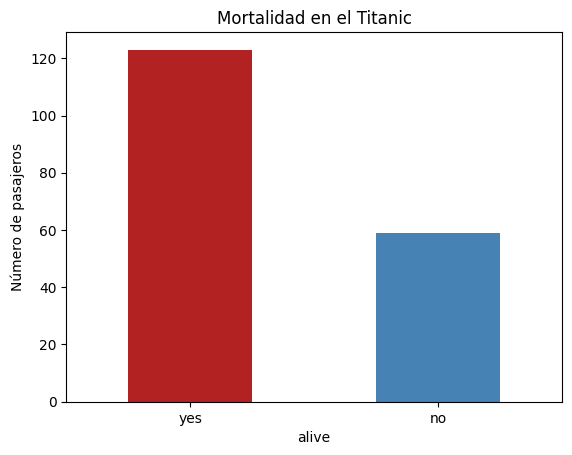

In [22]:
(df_titanic["alive"]
 .value_counts()
 .plot(kind="bar", color=["firebrick", "steelblue"]))
plt.title("Mortalidad en el Titanic")
plt.ylabel("Número de pasajeros")
plt.xticks(rotation=0)
plt.show()

In [11]:
#Supervivencia por sexo
tabla_sexo_abs = pd.crosstab(df_titanic["sex"], df_titanic["alive"])
tabla_sexo_abs

alive,no,yes
sex,,
female,6,82
male,53,41


In [12]:
tabla_sexo_pct = pd.crosstab(
    df_titanic["sex"],
    df_titanic["alive"],
    normalize="index"
) * 100

tabla_sexo_pct

alive,no,yes
sex,,
female,6.818182,93.181818
male,56.382979,43.617021


In [13]:
#Tabla "who"
tabla_who_abs = pd.crosstab(df_titanic["who"], df_titanic["alive"])
tabla_who_abs


alive,no,yes
who,,
child,2,11
man,53,34
woman,4,78


In [14]:
tabla_who_pct = pd.crosstab(
    df_titanic["who"],
    df_titanic["alive"],
    normalize="index"
) * 100

tabla_who_pct

alive,no,yes
who,,
child,15.384615,84.615385
man,60.919540,39.080460
woman,4.878049,95.121951


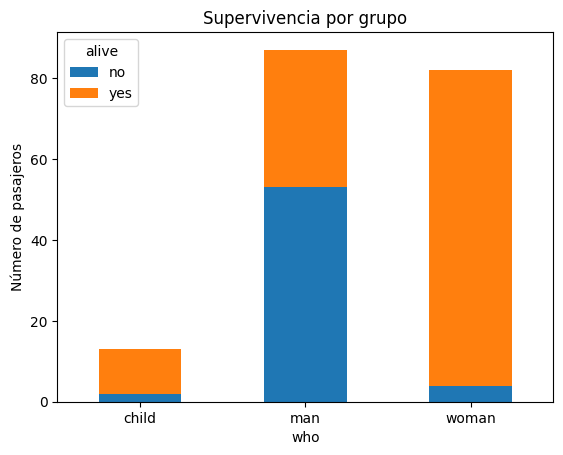

In [23]:
tabla = pd.crosstab(df_titanic["who"], df_titanic["alive"])

tabla.plot(kind="bar", stacked=True)
plt.title("Supervivencia por grupo")
plt.ylabel("Número de pasajeros")
plt.xticks(rotation=0)
plt.show()

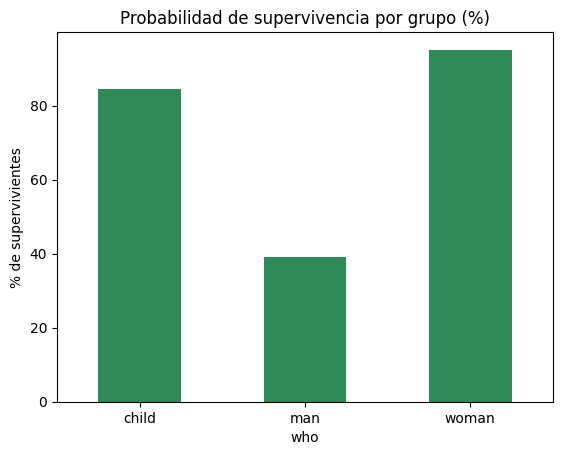

In [24]:
tabla_pct = pd.crosstab(
    df_titanic["who"],
    df_titanic["alive"],
    normalize="index"
) * 100

tabla_pct["yes"].plot(kind="bar", color="seagreen")
plt.title("Probabilidad de supervivencia por grupo (%)")
plt.ylabel("% de supervivientes")
plt.xticks(rotation=0)
plt.show()

In [15]:
# Por clase
tabla_clase_abs = pd.crosstab(df_titanic["class"], df_titanic["alive"])
tabla_clase_abs

alive,no,yes
class,,
First,51,106
Second,3,12
Third,5,5


In [16]:
tabla_clase_pct = pd.crosstab(
    df_titanic["class"],
    df_titanic["alive"],
    normalize="index"
) * 100

tabla_clase_pct

alive,no,yes
class,,
First,32.484076,67.515924
Second,20.000000,80.000000
Third,50.000000,50.000000


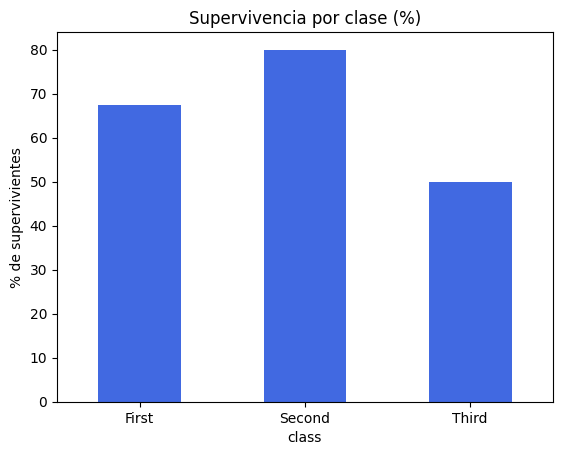

In [25]:
tabla_clase = pd.crosstab(
    df_titanic["class"],
    df_titanic["alive"],
    normalize="index"
) * 100

tabla_clase["yes"].plot(kind="bar", color="royalblue")
plt.title("Supervivencia por clase (%)")
plt.ylabel("% de supervivientes")
plt.xticks(rotation=0)
plt.show()

In [17]:
#Por ciudad de embarque
tabla_ciudad_abs = pd.crosstab(df_titanic["embark_town"], df_titanic["alive"])
tabla_ciudad_abs

alive,no,yes
embark_town,,
Cherbourg,17,48
Queenstown,1,1
Southampton,41,74


In [18]:
tabla_ciudad_pct = pd.crosstab(
    df_titanic["embark_town"],
    df_titanic["alive"],
    normalize="index"
) * 100

tabla_ciudad_pct

alive,no,yes
embark_town,,
Cherbourg,26.153846,73.846154
Queenstown,50.000000,50.000000
Southampton,35.652174,64.347826


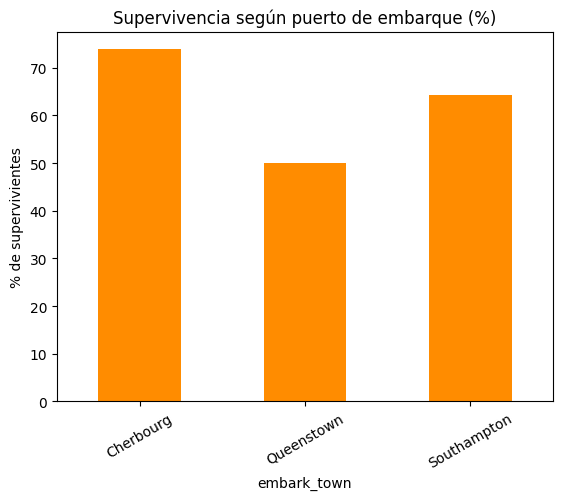

In [26]:
tabla_puerto = pd.crosstab(
    df_titanic["embark_town"],
    df_titanic["alive"],
    normalize="index"
) * 100

tabla_puerto["yes"].plot(kind="bar", color="darkorange")
plt.title("Supervivencia según puerto de embarque (%)")
plt.ylabel("% de supervivientes")
plt.xticks(rotation=30)
plt.show()

In [19]:
#Clase y supervivencia
pd.crosstab(
    df_titanic["class"],
    df_titanic["alive"],
    normalize="index"
) * 100

alive,no,yes
class,,
First,32.484076,67.515924
Second,20.000000,80.000000
Third,50.000000,50.000000


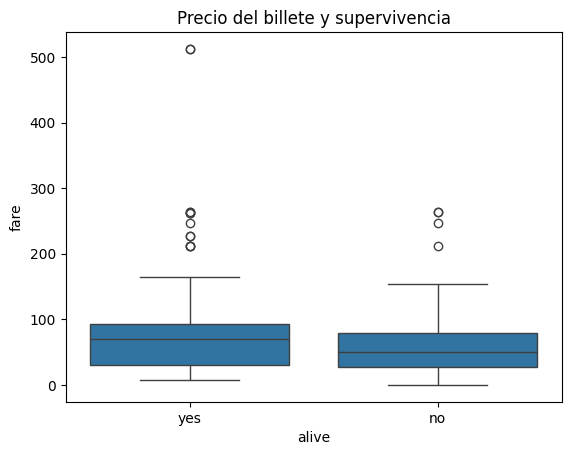

In [27]:
sns.boxplot(data=df_titanic, x="alive", y="fare")
plt.title("Precio del billete y supervivencia")
plt.show()

#2.2 Las gráficas a emplear en la presentación debes generarlas en un notebook.  

Tienes que entregar ambas cosas: presentación y notebook :)